In [66]:
import numpy as np    #importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

## Load Dataset

In [39]:
df=pd.read_csv("advertising.csv")
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


## CHECKING NULL VALUES 

In [40]:
df.isnull().sum()==0

TV           True
Radio        True
Newspaper    True
Sales        True
dtype: bool

## ## Split Dataset and Import Linear Regression Model

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [59]:
## Define Input Features and Target Variable

In [42]:
X = df[['TV']]     # input feature

y = df['Sales']    # output

## Split Dataset into Training and Testing Sets

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Linear Regression Model


In [44]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Model Coefficients and Intercept

In [45]:
print("Slope =", model.coef_)

print("Intercept =", np.round(model.intercept_).astype(int))

Slope = [0.05548294]
Intercept = 7


## Predict Sales Values and Compare Results

In [68]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

comparison.head()

,Actual Sales,Predicted Sales
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719


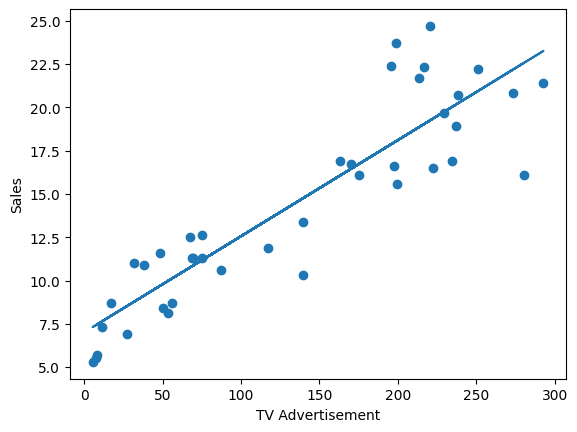

In [47]:
plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("TV Advertisement")

plt.ylabel("Sales")

plt.show()

## Import Model Evaluation Metrics

In [48]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print(score)

0.802561303423698


## Select Multiple Features and Target Variable

In [49]:
X2 = df[['TV','Radio', 'Newspaper'] ]     # input feature

y2 = df['Sales']

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

In [52]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
print("Slope =", np.round( model.coef_,3))

print("Intercept =",model.intercept_)

Slope = [0.055 0.101 0.004]
Intercept = 4.714126402214127


## Predict Sales Values and Compare Results

In [67]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

print(comparison.head())    

   Actual Sales  Predicted Sales
0          16.9        17.034772
1          22.4        20.409740
2          21.4        23.723989
3           7.3         9.272785
4          24.7        21.682719


## Evaluate Model Performance Using Error Metrics

In [55]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE =", mean_absolute_error(y_test,y_pred))
print("MSE =", mean_squared_error(y_test,y_pred))
print("R2 =", r2_score(y_test,y_pred))

MAE = 1.2748262109549338
MSE = 2.9077569102710896
R2 = 0.9059011844150826


## Visualize Actual vs Predicted Sales

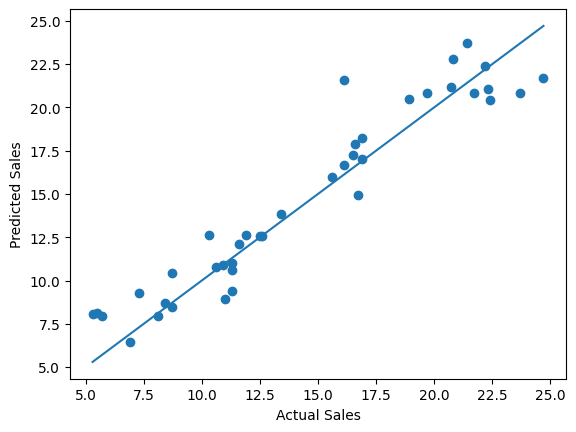

In [56]:
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)


plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.show()

## Select Multiple Features and Target Variable

In [57]:
print("MAE:", mean_absolute_error(y_test,y_pred))
print("MSE:", mean_squared_error(y_test,y_pred))
print("R2:", r2_score(y_test,y_pred))

MAE: 1.2748262109549338
MSE: 2.9077569102710896
R2: 0.9059011844150826
